# Project 1. TTI Endogenous Feature EDA

This notebook performs exploratory data analysis for the **Project 1 endogenous-only gold table**.

It is designed for:
- large datasets
- step-by-step inspection
- paper-ready summary tables and figures

Update the **USER CONFIGURATION** cell first.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

## 1. User configuration

In [2]:
# ============================================================
# USER CONFIGURATION
# ============================================================
# Intended notebook location:
# notebooks/5_EDA_project_2/ or similar EDA folder

PROJECT_ROOT = Path.cwd().parents[2]   # adjust if needed
DATA_DIR = PROJECT_ROOT / "Data"

GOLD_DIR = DATA_DIR / "c_final_tables" / "baseline_model_gold_table"
GOLD_FILE = "I66_phase1_TTI_features_2022_2025_combined.parquet"   # change if needed

OUT_DIR = Path.cwd() / "outputs_project1_eda"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_SIZE = 20000
PAIRPLOT_SAMPLE = 5000

gold_path = GOLD_DIR / GOLD_FILE

print("PROJECT_ROOT:", PROJECT_ROOT)
print("GOLD FILE:", gold_path)
print("OUT_DIR:", OUT_DIR)
print("Gold exists?", gold_path.exists())

PROJECT_ROOT: c:\Users\asinha\Coding_KAI\_Own_project\Congestion Regime Prediction
GOLD FILE: c:\Users\asinha\Coding_KAI\_Own_project\Congestion Regime Prediction\Data\c_final_tables\baseline_model_gold_table\I66_phase1_TTI_features_2022_2025_combined.parquet
OUT_DIR: c:\Users\asinha\Coding_KAI\_Own_project\Congestion Regime Prediction\notebooks\5_EDA\project_1\outputs_project1_eda
Gold exists? True


## 2. Load gold table

In [3]:
if gold_path.suffix.lower() == ".parquet":
    gold = pd.read_parquet(gold_path)
else:
    gold = pd.read_csv(gold_path, low_memory=False)

if "ts_utc" in gold.columns:
    gold["ts_utc"] = pd.to_datetime(gold["ts_utc"], utc=True, errors="coerce")
if "ts_local" in gold.columns:
    gold["ts_local"] = pd.to_datetime(gold["ts_local"], errors="coerce")

print("Shape:", gold.shape)
display(gold.head(5))
gold.info()

Shape: (17229104, 44)


,tmc,direction,ts_utc,ts_local,road,miles,tti,confidence,tti_missing_flag,year,month_number,day_of_week_number,hour_of_day,minute_of_hour,is_weekend_flag,sin_hour,cos_hour,sin_day_of_week,cos_day_of_week,sin_month,cos_month,target_tti_5min_ahead,target_tti_15min_ahead,target_tti_30min_ahead,tti_lag_1,tti_lag_2,tti_lag_3,tti_lag_4,tti_lag_5,tti_lag_6,tti_lag_7,tti_lag_8,tti_lag_9,tti_lag_10,tti_lag_11,tti_lag_12,tti_rolling_mean_6,tti_rolling_mean_12,tti_rolling_standard_deviation_6,tti_rolling_standard_deviation_12,tti_change_1_step,tti_absolute_change_1_step,is_low_confidence_flag,source_year
0,110+04164,WESTBOUND,2022-01-01 06:00:00+00:00,2022-01-01 01:00:00-05:00,I-66,0.103042,0.892857,30.0,0,2022.0,1.0,5.0,1.0,0.0,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,0.944882,0.933852,0.933852,0.872727,0.877514,0.919540,1.000208,1.021277,0.996678,0.963855,0.960384,0.926641,0.949179,0.909091,0.960000,0.947991,0.946425,0.066195,0.047097,-0.004786,0.004786,0,2022
1,110+04164,WESTBOUND,2022-01-01 06:05:00+00:00,2022-01-01 01:05:00-05:00,I-66,0.103042,0.944882,30.0,0,2022.0,1.0,5.0,1.0,5.0,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,0.934034,0.923077,0.941176,0.892857,0.872727,0.877514,0.919540,1.000208,1.021277,0.996678,0.963855,0.960384,0.926641,0.949179,0.909091,0.930687,0.940829,0.064470,0.049276,0.020130,0.020130,0,2022
2,110+04164,WESTBOUND,2022-01-01 06:10:00+00:00,2022-01-01 01:10:00-05:00,I-66,0.103042,0.934034,30.0,0,2022.0,1.0,5.0,1.0,10.0,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,0.933852,0.923077,0.949179,0.944882,0.892857,0.872727,0.877514,0.919540,1.000208,1.021277,0.996678,0.963855,0.960384,0.926641,0.949179,0.917955,0.943812,0.048588,0.048252,0.052025,0.052025,0,2022
3,110+04164,WESTBOUND,2022-01-01 06:15:00+00:00,2022-01-01 01:15:00-05:00,I-66,0.103042,0.933852,30.0,0,2022.0,1.0,5.0,1.0,15.0,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,0.923077,0.933852,0.937866,0.934034,0.944882,0.892857,0.872727,0.877514,0.919540,1.000208,1.021277,0.996678,0.963855,0.960384,0.926641,0.906926,0.942550,0.030223,0.048297,-0.010848,0.010848,0,2022
4,110+04164,WESTBOUND,2022-01-01 06:20:00+00:00,2022-01-01 01:20:00-05:00,I-66,0.103042,0.923077,30.0,0,2022.0,1.0,5.0,1.0,20.0,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,0.923077,0.941176,0.967937,0.933852,0.934034,0.944882,0.892857,0.872727,0.877514,0.919540,1.000208,1.021277,0.996678,0.963855,0.960384,0.909311,0.943151,0.031934,0.048126,-0.000182,0.000182,0,2022


<class 'pandas.DataFrame'>
RangeIndex: 17229104 entries, 0 to 17229103
Data columns (total 44 columns):
 #   Column                             Dtype                           
---  ------                             -----                           
 0   tmc                                str                             
 1   direction                          str                             
 2   ts_utc                             datetime64[us, UTC]             
 3   ts_local                           datetime64[us, America/New_York]
 4   road                               str                             
 5   miles                              float64                         
 6   tti                                float64                         
 7   confidence                         float64                         
 8   tti_missing_flag                   Int64                           
 9   year                               float64                         
 10  month_number   

## 3. Variable groups

In [4]:
CORE_VARS = [
    "tti",
    "target_tti_5min_ahead",
    "target_tti_15min_ahead",
    "target_tti_30min_ahead"
]

LAG_VARS = [f"tti_lag_{i}" for i in range(1, 13)]

ROLLING_VARS = [
    "tti_rolling_mean_6",
    "tti_rolling_mean_12",
    "tti_rolling_standard_deviation_6",
    "tti_rolling_standard_deviation_12"
]

CHANGE_VARS = [
    "tti_change_1_step",
    "tti_absolute_change_1_step"
]

TIME_VARS = [
    "hour_of_day",
    "day_of_week_number",
    "month_number",
    "is_weekend_flag"
]

META_VARS = [
    "tmc", "direction", "road", "miles", "year", "source_year",
    "confidence", "tti_missing_flag", "is_low_confidence_flag"
]

print("Core vars:", CORE_VARS)
print("Lag vars:", LAG_VARS)
print("Rolling vars:", ROLLING_VARS)
print("Change vars:", CHANGE_VARS)
print("Time vars:", TIME_VARS)

Core vars: ['tti', 'target_tti_5min_ahead', 'target_tti_15min_ahead', 'target_tti_30min_ahead']
Lag vars: ['tti_lag_1', 'tti_lag_2', 'tti_lag_3', 'tti_lag_4', 'tti_lag_5', 'tti_lag_6', 'tti_lag_7', 'tti_lag_8', 'tti_lag_9', 'tti_lag_10', 'tti_lag_11', 'tti_lag_12']
Rolling vars: ['tti_rolling_mean_6', 'tti_rolling_mean_12', 'tti_rolling_standard_deviation_6', 'tti_rolling_standard_deviation_12']
Change vars: ['tti_change_1_step', 'tti_absolute_change_1_step']
Time vars: ['hour_of_day', 'day_of_week_number', 'month_number', 'is_weekend_flag']


## 4. Basic QA and missingness

In [5]:
print("Duplicate (tmc, ts_utc):", gold[["tmc", "ts_utc"]].duplicated().sum())
print("Null ts_utc:", gold["ts_utc"].isna().sum())
print("Null tmc:", gold["tmc"].isna().sum())

missing_pct = gold.isna().mean().mul(100).round(2).sort_values(ascending=False)
display(missing_pct.to_frame("missing_pct").head(40))

basic_summary = pd.DataFrame({
    "metric": [
        "rows", "cols", "tmc_count", "start_ts_utc", "end_ts_utc",
        "tti_missing_pct", "low_confidence_pct"
    ],
    "value": [
        len(gold),
        gold.shape[1],
        gold["tmc"].nunique() if "tmc" in gold.columns else np.nan,
        gold["ts_utc"].min(),
        gold["ts_utc"].max(),
        gold["tti"].isna().mean() * 100 if "tti" in gold.columns else np.nan,
        gold["is_low_confidence_flag"].mean() * 100 if "is_low_confidence_flag" in gold.columns else np.nan,
    ]
})
display(basic_summary)
basic_summary.to_csv(TABLE_DIR / "basic_summary.csv", index=False)

Duplicate (tmc, ts_utc): 0
Null ts_utc: 0
Null tmc: 0


,missing_pct
tmc,0.0
direction,0.0
ts_utc,0.0
ts_local,0.0
road,0.0
miles,0.0
tti,0.0
confidence,0.0
tti_missing_flag,0.0
year,0.0


,metric,value
0,rows,17229104
1,cols,44
2,tmc_count,41
3,start_ts_utc,2022-01-01 06:00:00+00:00
4,end_ts_utc,2026-01-01 04:25:00+00:00
5,tti_missing_pct,0.0
6,low_confidence_pct,0.598452


## 5. Create helper columns for EDA

In [6]:
gold = gold.copy()

gold["volatility_30min"] = gold["tti_rolling_standard_deviation_12"]

gold["regime"] = np.select(
    [
        gold["tti"] < 1.15,
        gold["tti"] < 1.30,
        gold["tti"] < 2.00
    ],
    ["Free Flow", "Moderate", "Heavy"],
    default="Severe"
)

gold["is_congested"] = (gold["tti"] >= 1.30).astype(int)
gold["future_change_5"] = (gold["target_tti_5min_ahead"] - gold["tti"]).abs()
gold["future_change_15"] = (gold["target_tti_15min_ahead"] - gold["tti"]).abs()
gold["future_change_30"] = (gold["target_tti_30min_ahead"] - gold["tti"]).abs()

display(gold[["tti", "volatility_30min", "regime", "is_congested", "future_change_30"]].head(10))

,tti,volatility_30min,regime,is_congested,future_change_30
0,0.892857,0.047097,Free Flow,0,0.040995
1,0.944882,0.049276,Free Flow,0,0.003705
2,0.934034,0.048252,Free Flow,0,0.015145
3,0.933852,0.048297,Free Flow,0,0.004014
4,0.923077,0.048126,Free Flow,0,0.044860
5,0.923077,0.048117,Free Flow,0,0.036923
6,0.933852,0.047720,Free Flow,0,0.026148
7,0.941176,0.043822,Free Flow,0,0.034433
8,0.949179,0.033856,Free Flow,0,0.096117
9,0.937866,0.025748,Free Flow,0,0.105612


## 6. Summary statistics for paper

In [7]:
summary_stats = gold[
    [c for c in [
        "tti",
        "target_tti_5min_ahead",
        "target_tti_15min_ahead",
        "target_tti_30min_ahead",
        "volatility_30min",
        "tti_change_1_step",
        "tti_absolute_change_1_step"
    ] if c in gold.columns]
].describe().T.round(3)

display(summary_stats)
summary_stats.to_csv(TABLE_DIR / "summary_statistics_core.csv")

,count,mean,std,min,25%,50%,75%,max
tti,17229104.0,1.102,0.528,0.658,0.966,1.000,1.051,60.000
target_tti_5min_ahead,17229104.0,1.102,0.528,0.658,0.966,1.000,1.051,60.000
target_tti_15min_ahead,17229104.0,1.102,0.528,0.658,0.966,1.000,1.051,60.000
target_tti_30min_ahead,17229104.0,1.102,0.528,0.658,0.966,1.000,1.051,60.000
volatility_30min,17229104.0,0.093,0.253,0.000,0.026,0.036,0.053,24.869
tti_change_1_step,17229104.0,0.000,0.201,-48.107,-0.024,0.000,0.025,55.327
tti_absolute_change_1_step,17229104.0,0.057,0.193,0.000,0.010,0.024,0.047,55.327


## 7. TTI distribution

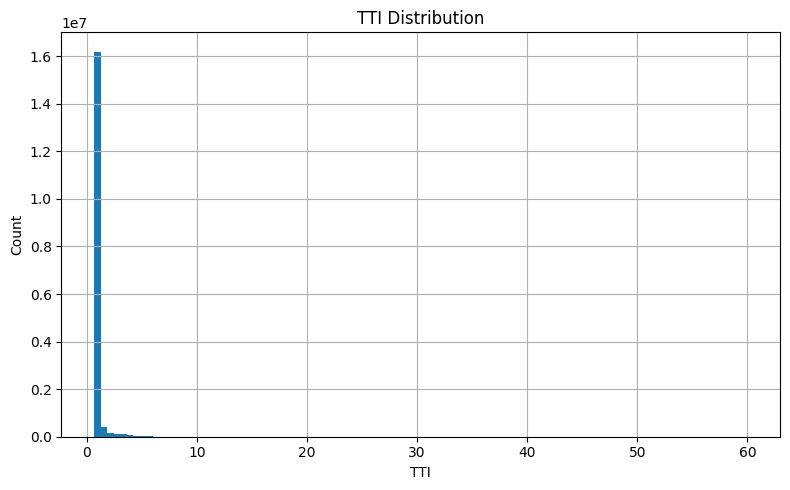

,count,mean,std,min,25%,50%,75%,max
direction,,,,,,,,
EASTBOUND,8404629.0,1.138,0.606,0.658,0.967,1.0,1.052,60.0
WESTBOUND,8824475.0,1.067,0.438,0.680,0.966,1.0,1.050,55.0


In [8]:
plt.figure(figsize=(8,5))
gold["tti"].dropna().hist(bins=100)
plt.title("TTI Distribution")
plt.xlabel("TTI")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "tti_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

tti_by_direction = gold.groupby("direction", dropna=False)["tti"].describe().round(3)
display(tti_by_direction)
tti_by_direction.to_csv(TABLE_DIR / "tti_by_direction_summary.csv")

## 8. TTI by hour of day

,hour_of_day,direction,tti
0,0.0,EASTBOUND,1.024579
1,0.0,WESTBOUND,1.014696
2,1.0,EASTBOUND,1.042522
3,1.0,WESTBOUND,1.029649
4,2.0,EASTBOUND,1.054519
5,2.0,WESTBOUND,1.033096
6,3.0,EASTBOUND,1.031322
7,3.0,WESTBOUND,1.032588
8,4.0,EASTBOUND,0.983565
9,4.0,WESTBOUND,1.007551


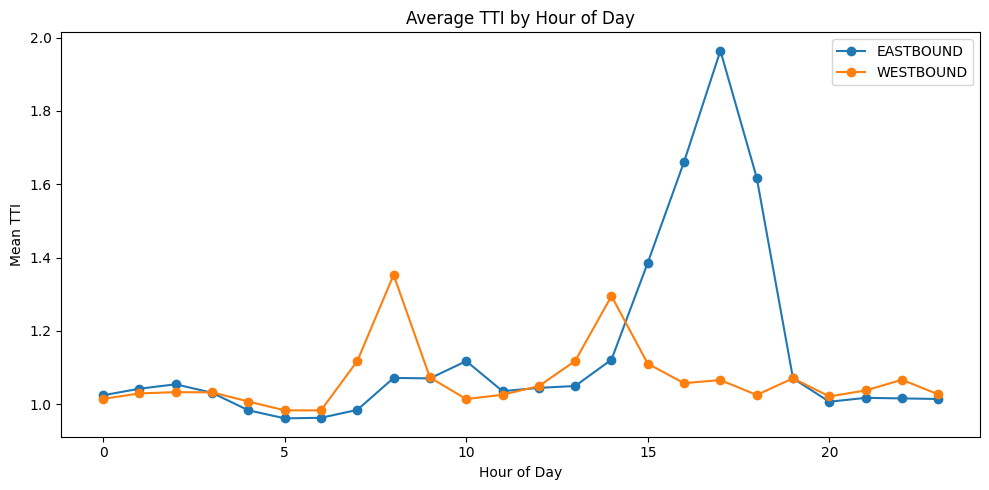

In [9]:
hourly_tti = (
    gold.groupby(["hour_of_day", "direction"], as_index=False)["tti"]
    .mean()
)

display(hourly_tti.head(20))

plt.figure(figsize=(10,5))
for d in sorted(hourly_tti["direction"].dropna().unique()):
    temp = hourly_tti[hourly_tti["direction"] == d]
    plt.plot(temp["hour_of_day"], temp["tti"], marker="o", label=d)
plt.title("Average TTI by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Mean TTI")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "tti_by_hour_direction.png", dpi=200, bbox_inches="tight")
plt.show()

hourly_tti.to_csv(TABLE_DIR / "tti_by_hour_direction.csv", index=False)

## 9. TTI by day of week

,day_of_week_number,tti
0,0.0,1.062109
1,1.0,1.146177
2,2.0,1.156146
3,3.0,1.164958
4,4.0,1.109572
5,5.0,1.055946
6,6.0,1.018385


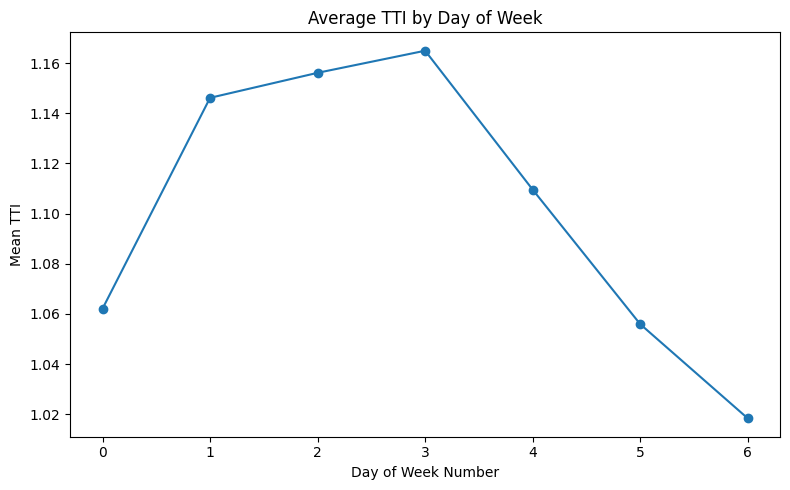

In [10]:
dow_tti = (
    gold.groupby("day_of_week_number", as_index=False)["tti"]
    .mean()
)

display(dow_tti)

plt.figure(figsize=(8,5))
plt.plot(dow_tti["day_of_week_number"], dow_tti["tti"], marker="o")
plt.title("Average TTI by Day of Week")
plt.xlabel("Day of Week Number")
plt.ylabel("Mean TTI")
plt.tight_layout()
plt.savefig(FIG_DIR / "tti_by_day_of_week.png", dpi=200, bbox_inches="tight")
plt.show()

dow_tti.to_csv(TABLE_DIR / "tti_by_day_of_week.csv", index=False)

## 10. TTI by month

,month_number,tti
0,1.0,1.069272
1,2.0,1.070545
2,3.0,1.100290
3,4.0,1.105992
4,5.0,1.122518
5,6.0,1.126093
6,7.0,1.080912
7,8.0,1.082280
8,9.0,1.115765
9,10.0,1.128096


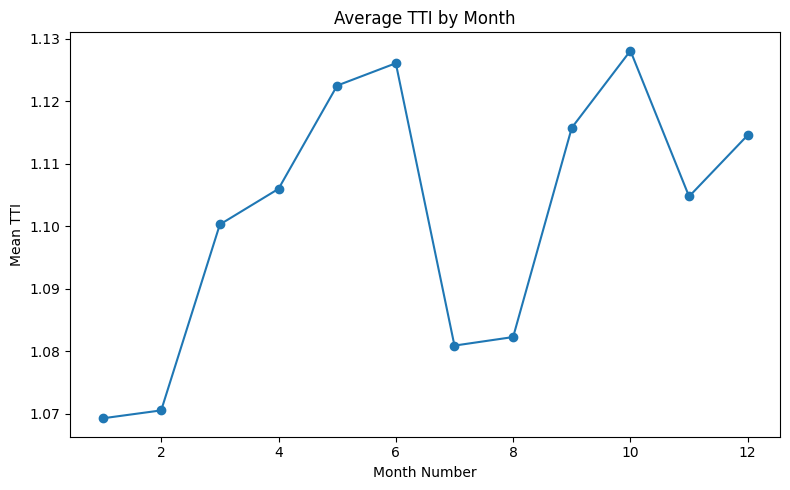

In [11]:
month_tti = (
    gold.groupby("month_number", as_index=False)["tti"]
    .mean()
)

display(month_tti)

plt.figure(figsize=(8,5))
plt.plot(month_tti["month_number"], month_tti["tti"], marker="o")
plt.title("Average TTI by Month")
plt.xlabel("Month Number")
plt.ylabel("Mean TTI")
plt.tight_layout()
plt.savefig(FIG_DIR / "tti_by_month.png", dpi=200, bbox_inches="tight")
plt.show()

month_tti.to_csv(TABLE_DIR / "tti_by_month.csv", index=False)

## 11. Regime and congestion summaries

,count,pct
regime,,
Free Flow,15636277,90.755021
Moderate,648310,3.762877
Severe,558505,3.241637
Heavy,386012,2.240465


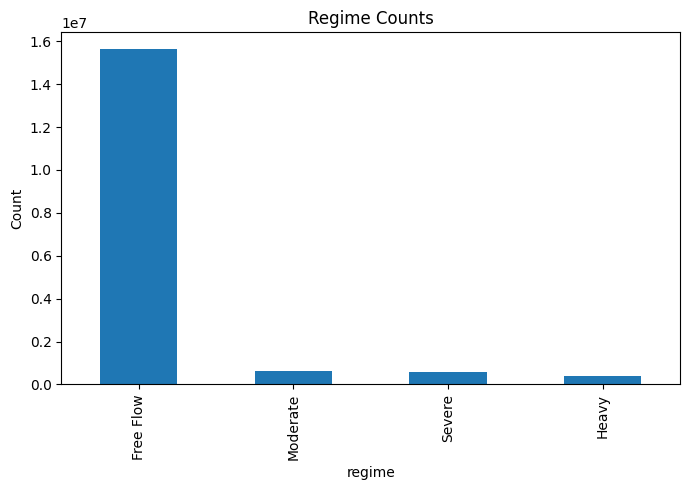

Congested pct: 5.48


In [12]:
regime_counts = gold["regime"].value_counts(dropna=False).to_frame("count")
regime_counts["pct"] = regime_counts["count"] / len(gold) * 100
display(regime_counts)
regime_counts.to_csv(TABLE_DIR / "regime_counts.csv")

plt.figure(figsize=(7,5))
regime_counts["count"].plot(kind="bar")
plt.title("Regime Counts")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "regime_counts.png", dpi=200, bbox_inches="tight")
plt.show()

congested_rate = gold["is_congested"].mean() * 100
print("Congested pct:", round(congested_rate, 2))

## 12. Volatility analysis

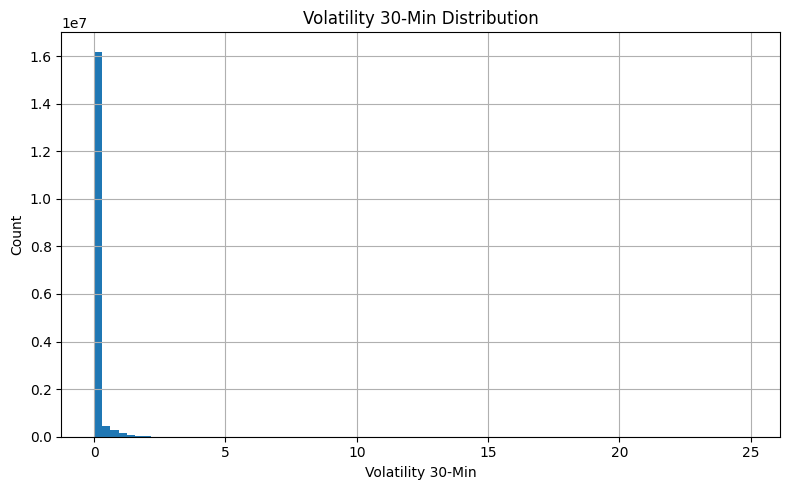

,tmc,direction,volatility_30min
23,110N04167,EASTBOUND,0.174647
14,110-04167,EASTBOUND,0.168646
24,110N04168,EASTBOUND,0.163668
33,110P04166,WESTBOUND,0.156093
25,110N04169,EASTBOUND,0.145886
20,110N04164,EASTBOUND,0.132363
15,110-04168,EASTBOUND,0.128323
16,110-04169,EASTBOUND,0.125950
10,110-04163,EASTBOUND,0.124546
5,110+04169,WESTBOUND,0.122184


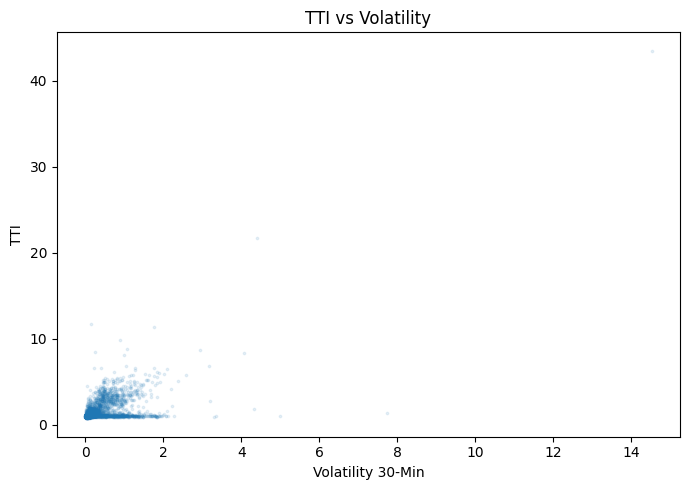

In [13]:
plt.figure(figsize=(8,5))
gold["volatility_30min"].dropna().hist(bins=80)
plt.title("Volatility 30-Min Distribution")
plt.xlabel("Volatility 30-Min")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "volatility_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

vol_by_tmc = (
    gold.groupby(["tmc", "direction"], as_index=False)["volatility_30min"]
    .mean()
    .sort_values("volatility_30min", ascending=False)
)
display(vol_by_tmc.head(20))
vol_by_tmc.to_csv(TABLE_DIR / "volatility_by_tmc.csv", index=False)

sample = gold[["volatility_30min", "tti"]].dropna()
sample = sample.sample(min(SAMPLE_SIZE, len(sample)), random_state=42)

plt.figure(figsize=(7,5))
plt.scatter(sample["volatility_30min"], sample["tti"], s=3, alpha=0.1)
plt.title("TTI vs Volatility")
plt.xlabel("Volatility 30-Min")
plt.ylabel("TTI")
plt.tight_layout()
plt.savefig(FIG_DIR / "tti_vs_volatility.png", dpi=200, bbox_inches="tight")
plt.show()

## 13. Future TTI vs current TTI

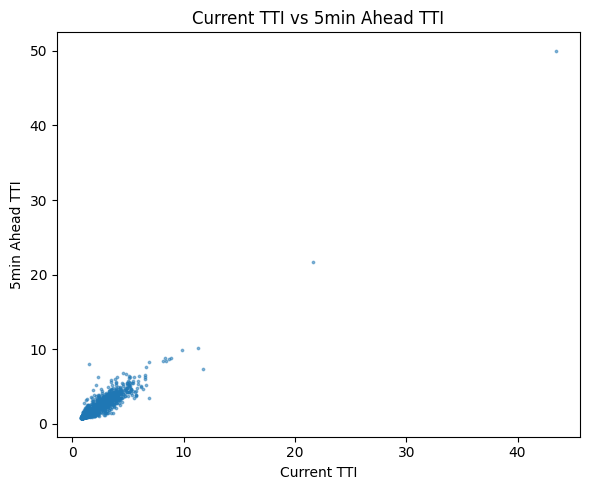

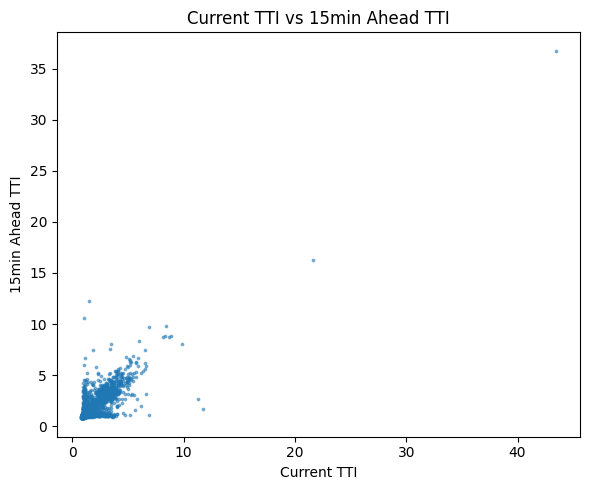

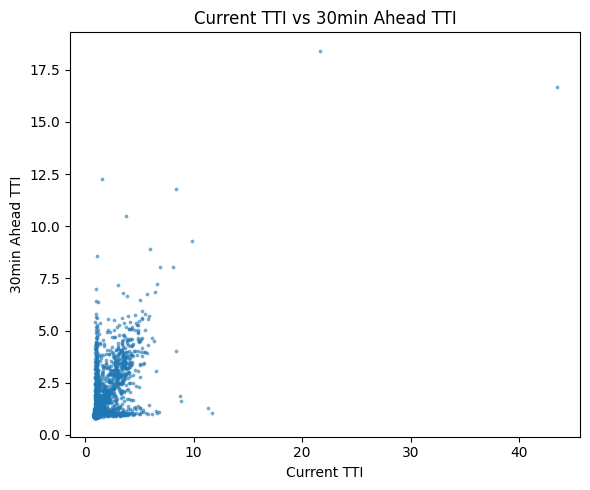

In [14]:
for target_col, name in [
    ("target_tti_5min_ahead", "5min"),
    ("target_tti_15min_ahead", "15min"),
    ("target_tti_30min_ahead", "30min"),
]:
    temp = gold[["tti", target_col]].dropna()
    temp = temp.sample(min(SAMPLE_SIZE, len(temp)), random_state=42)

    plt.figure(figsize=(6,5))
    plt.scatter(temp["tti"], temp[target_col], s=3, alpha=0.5)
    plt.title(f"Current TTI vs {name} Ahead TTI")
    plt.xlabel("Current TTI")
    plt.ylabel(f"{name} Ahead TTI")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"tti_vs_{name}_ahead.png", dpi=200, bbox_inches="tight")
    plt.show()

## 14. Lag correlation plot

,lag_step,correlation
0,1,0.927559
1,2,0.852633
2,3,0.791360
3,4,0.736767
4,5,0.686881
5,6,0.643446
6,7,0.603793
7,8,0.568377
8,9,0.535435
9,10,0.505821


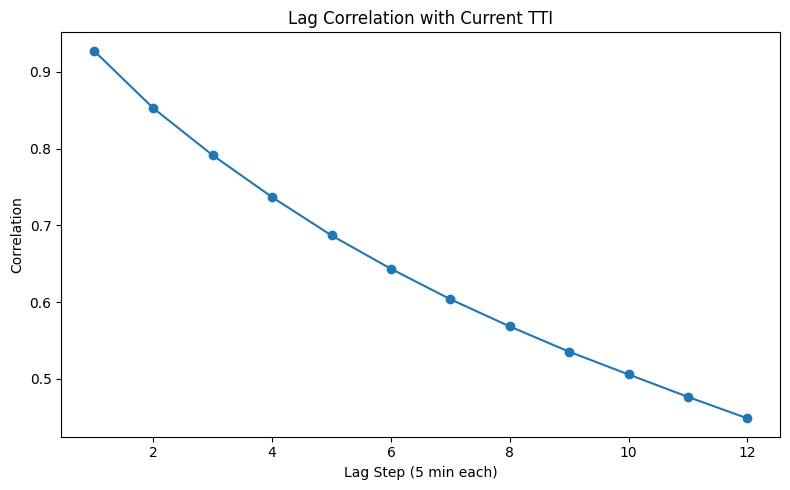

In [15]:
lag_corr = []
for i in range(1, 13):
    col = f"tti_lag_{i}"
    corr = gold["tti"].corr(gold[col])
    lag_corr.append({"lag_step": i, "correlation": corr})

lag_corr_df = pd.DataFrame(lag_corr)
display(lag_corr_df)
lag_corr_df.to_csv(TABLE_DIR / "lag_correlation.csv", index=False)

plt.figure(figsize=(8,5))
plt.plot(lag_corr_df["lag_step"], lag_corr_df["correlation"], marker="o")
plt.title("Lag Correlation with Current TTI")
plt.xlabel("Lag Step (5 min each)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.savefig(FIG_DIR / "lag_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

## 15. Horizon correlation plot

,horizon,correlation
0,5 min,0.927540
1,15 min,0.791182
2,30 min,0.643061


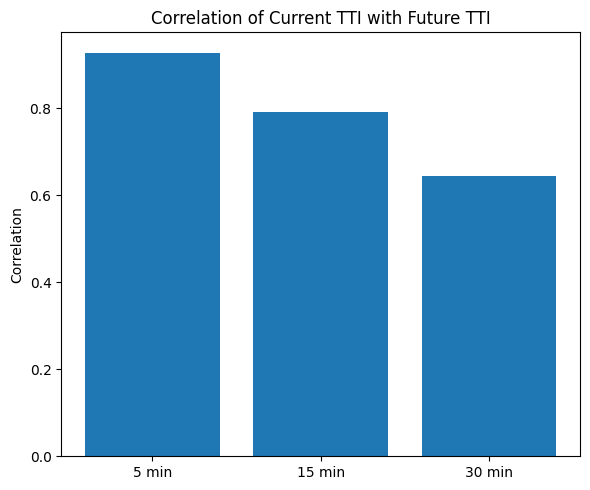

In [16]:
horizon_corr = pd.DataFrame({
    "horizon": ["5 min", "15 min", "30 min"],
    "correlation": [
        gold["tti"].corr(gold["target_tti_5min_ahead"]),
        gold["tti"].corr(gold["target_tti_15min_ahead"]),
        gold["tti"].corr(gold["target_tti_30min_ahead"]),
    ]
})
display(horizon_corr)
horizon_corr.to_csv(TABLE_DIR / "horizon_correlation.csv", index=False)

plt.figure(figsize=(6,5))
plt.bar(horizon_corr["horizon"], horizon_corr["correlation"])
plt.title("Correlation of Current TTI with Future TTI")
plt.ylabel("Correlation")
plt.tight_layout()
plt.savefig(FIG_DIR / "horizon_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

## 16. Predictability ceiling style plot. Future change vs volatility

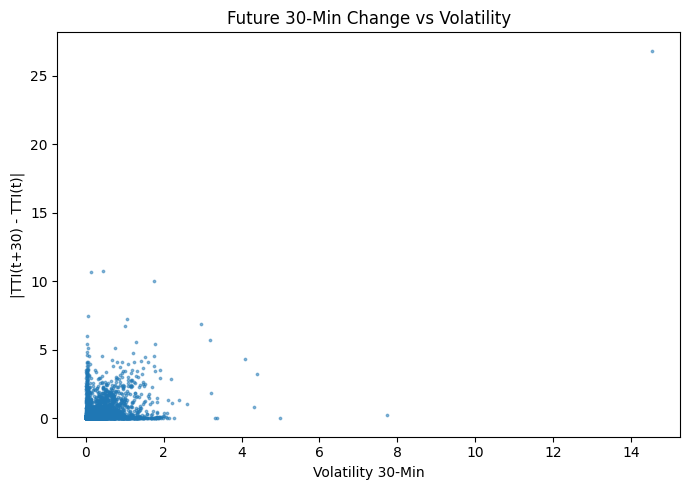

In [17]:
sample = gold[["volatility_30min", "future_change_30"]].dropna()
sample = sample.sample(min(SAMPLE_SIZE, len(sample)), random_state=42)

plt.figure(figsize=(7,5))
plt.scatter(sample["volatility_30min"], sample["future_change_30"], s=3, alpha=0.5)
plt.title("Future 30-Min Change vs Volatility")
plt.xlabel("Volatility 30-Min")
plt.ylabel("|TTI(t+30) - TTI(t)|")
plt.tight_layout()
plt.savefig(FIG_DIR / "future_change_vs_volatility.png", dpi=200, bbox_inches="tight")
plt.show()

## 17. Momentum features

,count,mean,std,min,25%,50%,75%,max
tti_change_1_step,17229104.0,0.000,0.201,-48.107,-0.024,0.000,0.025,55.327
tti_absolute_change_1_step,17229104.0,0.057,0.193,0.000,0.010,0.024,0.047,55.327


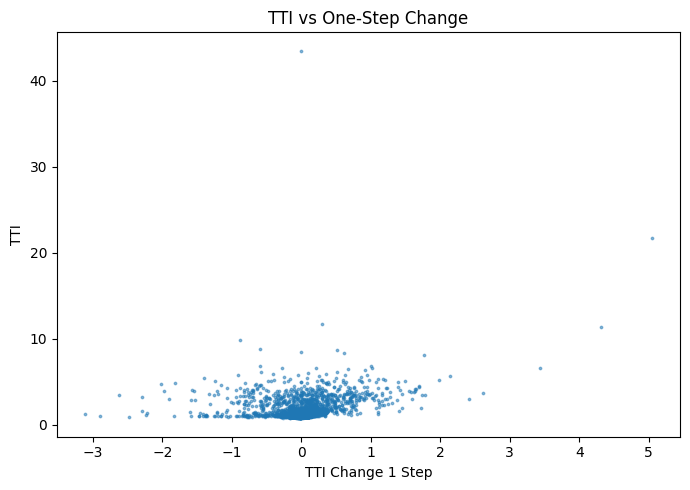

In [18]:
change_summary = gold[
    [c for c in ["tti_change_1_step", "tti_absolute_change_1_step"] if c in gold.columns]
].describe().T.round(3)
display(change_summary)
change_summary.to_csv(TABLE_DIR / "change_feature_summary.csv")

sample = gold[["tti_change_1_step", "tti"]].dropna()
sample = sample.sample(min(SAMPLE_SIZE, len(sample)), random_state=42)

plt.figure(figsize=(7,5))
plt.scatter(sample["tti_change_1_step"], sample["tti"], s=3, alpha=0.5)
plt.title("TTI vs One-Step Change")
plt.xlabel("TTI Change 1 Step")
plt.ylabel("TTI")
plt.tight_layout()
plt.savefig(FIG_DIR / "tti_vs_change_1_step.png", dpi=200, bbox_inches="tight")
plt.show()

## 18. Pair plot for key endogenous variables

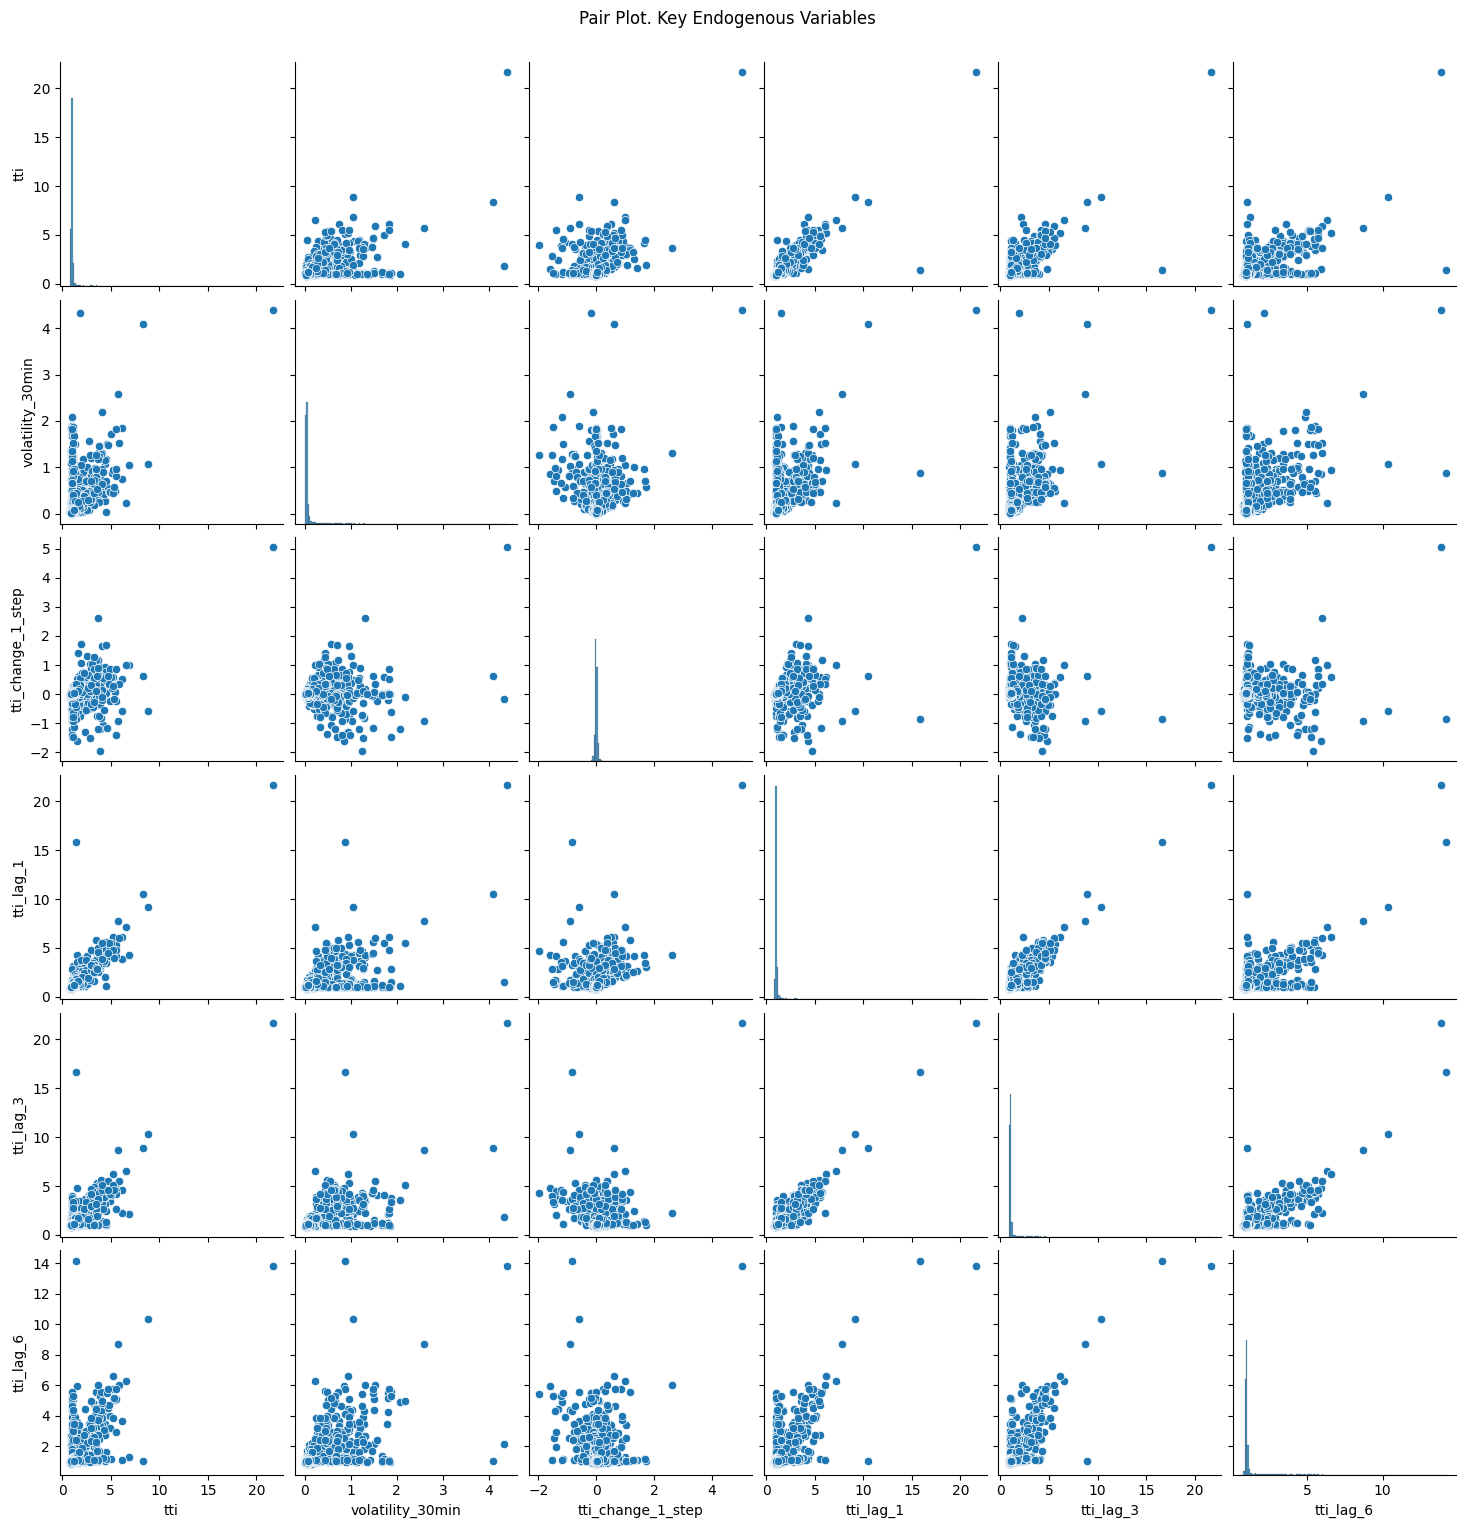

In [19]:
import seaborn as sns

pair_vars = [
    "tti",
    "volatility_30min",
    "tti_change_1_step",
    "tti_lag_1",
    "tti_lag_3",
    "tti_lag_6"
]

pair_df = gold[pair_vars].dropna()
pair_df = pair_df.sample(min(PAIRPLOT_SAMPLE, len(pair_df)), random_state=42)

g = sns.pairplot(pair_df, diag_kind="hist")
g.fig.suptitle("Pair Plot. Key Endogenous Variables", y=1.02)
g.fig.savefig(FIG_DIR / "pairplot_endogenous.png", dpi=200, bbox_inches="tight")
plt.show()

## 19. Correlation matrix for key endogenous variables

In [20]:
corr_cols = [
    "tti",
    "target_tti_5min_ahead",
    "target_tti_15min_ahead",
    "target_tti_30min_ahead",
    "tti_lag_1",
    "tti_lag_3",
    "tti_lag_6",
    "tti_lag_12",
    "volatility_30min",
    "tti_change_1_step",
    "tti_absolute_change_1_step"
]
corr_cols = [c for c in corr_cols if c in gold.columns]

corr_table = gold[corr_cols].corr(numeric_only=True).round(3)
display(corr_table)
corr_table.to_csv(TABLE_DIR / "correlation_table_endogenous.csv")

,tti,target_tti_5min_ahead,target_tti_15min_ahead,target_tti_30min_ahead,tti_lag_1,tti_lag_3,tti_lag_6,tti_lag_12,volatility_30min,tti_change_1_step,tti_absolute_change_1_step
tti,1.000,0.928,0.791,0.643,0.928,0.791,0.643,0.449,0.563,0.197,0.553
target_tti_5min_ahead,0.928,1.000,0.852,0.686,0.853,0.737,0.604,0.421,0.521,0.161,0.501
target_tti_15min_ahead,0.791,0.852,1.000,0.791,0.737,0.643,0.535,0.371,0.454,0.131,0.433
target_tti_30min_ahead,0.643,0.686,0.791,1.000,0.603,0.535,0.448,0.306,0.378,0.093,0.359
tti_lag_1,0.928,0.853,0.737,0.603,1.000,0.853,0.687,0.477,0.608,0.191,0.598
tti_lag_3,0.791,0.737,0.643,0.535,0.853,1.000,0.791,0.536,0.639,-0.197,0.556
tti_lag_6,0.643,0.604,0.535,0.448,0.687,0.791,1.000,0.643,0.652,-0.131,0.431
tti_lag_12,0.449,0.421,0.371,0.306,0.477,0.536,0.643,1.000,0.628,-0.077,0.291
volatility_30min,0.563,0.521,0.454,0.378,0.608,0.639,0.652,0.628,1.000,-0.055,0.513
tti_change_1_step,0.197,0.161,0.131,0.093,0.191,-0.197,-0.131,-0.077,-0.055,1.000,0.006


## 20. Example time series slice

Example TMC: 110+04164
Example rows: 2001


,tmc,direction,ts_utc,ts_local,road,miles,tti,confidence,tti_missing_flag,year,month_number,day_of_week_number,hour_of_day,minute_of_hour,is_weekend_flag,sin_hour,cos_hour,sin_day_of_week,cos_day_of_week,sin_month,cos_month,target_tti_5min_ahead,target_tti_15min_ahead,target_tti_30min_ahead,tti_lag_1,tti_lag_2,tti_lag_3,tti_lag_4,tti_lag_5,tti_lag_6,tti_lag_7,tti_lag_8,tti_lag_9,tti_lag_10,tti_lag_11,tti_lag_12,tti_rolling_mean_6,tti_rolling_mean_12,tti_rolling_standard_deviation_6,tti_rolling_standard_deviation_12,tti_change_1_step,tti_absolute_change_1_step,is_low_confidence_flag,source_year,volatility_30min,regime,is_congested,future_change_5,future_change_15,future_change_30
0,110+04164,WESTBOUND,2022-01-01 06:00:00+00:00,2022-01-01 01:00:00-05:00,I-66,0.103042,0.892857,30.0,0,2022.0,1.0,5.0,1.0,0.0,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,0.944882,0.933852,0.933852,0.872727,0.877514,0.919540,1.000208,1.021277,0.996678,0.963855,0.960384,0.926641,0.949179,0.909091,0.960000,0.947991,0.946425,0.066195,0.047097,-0.004786,0.004786,0,2022,0.047097,Free Flow,0,0.052025,0.040995,0.040995
1,110+04164,WESTBOUND,2022-01-01 06:05:00+00:00,2022-01-01 01:05:00-05:00,I-66,0.103042,0.944882,30.0,0,2022.0,1.0,5.0,1.0,5.0,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,0.934034,0.923077,0.941176,0.892857,0.872727,0.877514,0.919540,1.000208,1.021277,0.996678,0.963855,0.960384,0.926641,0.949179,0.909091,0.930687,0.940829,0.064470,0.049276,0.020130,0.020130,0,2022,0.049276,Free Flow,0,0.010848,0.021805,0.003705
2,110+04164,WESTBOUND,2022-01-01 06:10:00+00:00,2022-01-01 01:10:00-05:00,I-66,0.103042,0.934034,30.0,0,2022.0,1.0,5.0,1.0,10.0,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,0.933852,0.923077,0.949179,0.944882,0.892857,0.872727,0.877514,0.919540,1.000208,1.021277,0.996678,0.963855,0.960384,0.926641,0.949179,0.917955,0.943812,0.048588,0.048252,0.052025,0.052025,0,2022,0.048252,Free Flow,0,0.000182,0.010957,0.015145
3,110+04164,WESTBOUND,2022-01-01 06:15:00+00:00,2022-01-01 01:15:00-05:00,I-66,0.103042,0.933852,30.0,0,2022.0,1.0,5.0,1.0,15.0,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,0.923077,0.933852,0.937866,0.934034,0.944882,0.892857,0.872727,0.877514,0.919540,1.000208,1.021277,0.996678,0.963855,0.960384,0.926641,0.906926,0.942550,0.030223,0.048297,-0.010848,0.010848,0,2022,0.048297,Free Flow,0,0.010775,0.000000,0.004014
4,110+04164,WESTBOUND,2022-01-01 06:20:00+00:00,2022-01-01 01:20:00-05:00,I-66,0.103042,0.923077,30.0,0,2022.0,1.0,5.0,1.0,20.0,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,0.923077,0.941176,0.967937,0.933852,0.934034,0.944882,0.892857,0.872727,0.877514,0.919540,1.000208,1.021277,0.996678,0.963855,0.960384,0.909311,0.943151,0.031934,0.048126,-0.000182,0.000182,0,2022,0.048126,Free Flow,0,0.000000,0.018100,0.044860
5,110+04164,WESTBOUND,2022-01-01 06:25:00+00:00,2022-01-01 01:25:00-05:00,I-66,0.103042,0.923077,30.0,0,2022.0,1.0,5.0,1.0,25.0,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,0.933852,0.949179,0.960000,0.923077,0.933852,0.934034,0.944882,0.892857,0.872727,0.877514,0.919540,1.000208,1.021277,0.996678,0.963855,0.916905,0.940042,0.028041,0.048117,-0.010775,0.010775,0,2022,0.048117,Free Flow,0,0.010775,0.026102,0.036923
6,110+04164,WESTBOUND,2022-01-01 06:30:00+00:00,2022-01-01 01:30:00-05:00,I-66,0.103042,0.933852,30.0,0,2022.0,1.0,5.0,1.0,30.0,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,0.941176,0.937866,0.960000,0.923077,0.923077,0.933852,0.934034,0.944882,0.892857,0.872727,0.877514,0.919540,1.000208,1.021277,0.996678,0.925296,0.936644,0.017862,0.047720,0.000000,0.000000,0,2022,0.047720,Free Flow,0,0.007324,0.004014,0.026148
7,110+04164,WESTBOUND,2022-01-01 06:35:00+00:00,2022-01-01 01:35:00-05:00,I-66,0.103042,0.941176,30.0,0,2022.0,1.0,5.0,1.0,35.0,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,0.949179,0.967937,0.975610,0.933852,0.923077,0.923077,0.933852,0.934034,0.944882,0.892857,0.872727,0.877514,0.919540,1.000208,1.021277,0.932129,0.931408,0

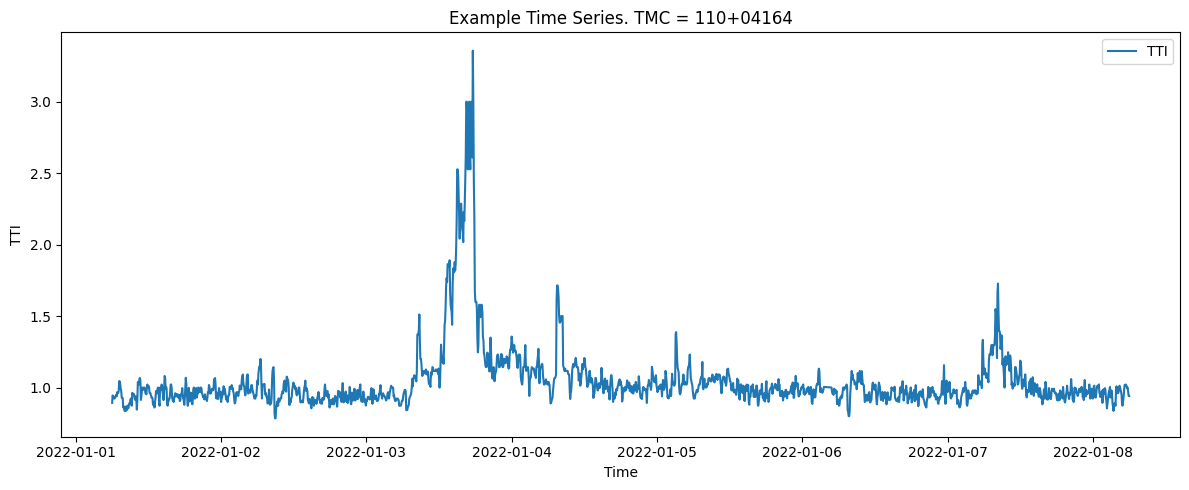

In [21]:
example_tmc = gold["tmc"].dropna().iloc[0]
example_start = gold["ts_utc"].dropna().min()
example_end = example_start + pd.Timedelta(days=7)

ts_example = gold[
    (gold["tmc"] == example_tmc) &
    (gold["ts_utc"] >= example_start) &
    (gold["ts_utc"] <= example_end)
].copy()

print("Example TMC:", example_tmc)
print("Example rows:", len(ts_example))
display(ts_example.head(10))

if len(ts_example) > 0:
    plt.figure(figsize=(12,5))
    plt.plot(ts_example["ts_utc"], ts_example["tti"], label="TTI")
    plt.title(f"Example Time Series. TMC = {example_tmc}")
    plt.xlabel("Time")
    plt.ylabel("TTI")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "example_time_series.png", dpi=200, bbox_inches="tight")
    plt.show()

# Peak vs Off-Peak Congestion Statistics

In [22]:
peak_hours_am = [6,7,8,9]
peak_hours_pm = [15,16,17,18]

gold["period"] = "Off-Peak"
gold.loc[gold["hour_of_day"].isin(peak_hours_am), "period"] = "AM Peak"
gold.loc[gold["hour_of_day"].isin(peak_hours_pm), "period"] = "PM Peak"

peak_summary = gold.groupby("period").agg(
    mean_tti=("tti", "mean"),
    std_tti=("tti", "std"),
    mean_change=("tti_absolute_change_1_step", "mean"),
    count=("tti", "count")
).reset_index()

display(peak_summary)

,period,mean_tti,std_tti,mean_change,count
0,AM Peak,1.078563,0.508666,0.055581,2873575
1,Off-Peak,1.044613,0.356281,0.041578,11481813
2,PM Peak,1.353966,0.909606,0.117123,2873716


In [ ]:
# whisker plot by period of time for TTI

plt.figure(figsize=(8,5))
sns.boxplot(x="period", y="tti", data=gold)
plt.title("TTI Distribution by Time Period")
plt.xlabel("Time Period")
plt.ylabel("TTI")
plt.ylim(0, 2.0)
plt.tight_layout() 

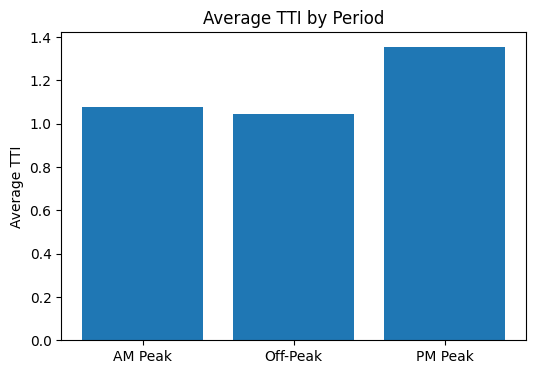

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(peak_summary["period"], peak_summary["mean_tti"])
plt.ylabel("Average TTI")
plt.title("Average TTI by Period")
plt.show()

# Section 2 – Segment Volatility Ranking

In [ ]:
# Segment Volatility Ranking
# =====================================

# Segment Volatility Ranking by Direction
# =====================================

segment_volatility = (
    gold.groupby(["tmc","direction"])
    .agg(tti_volatility=("tti","std"))
    .reset_index()
)

# Sort eastbound first, then westbound
segment_volatility_sorted = segment_volatility.sort_values(
    by=["tti_volatility"],
    ascending=False
)

# Create label for plotting
segment_volatility_sorted["tmc_dir"] = (
    segment_volatility_sorted["tmc"] + "_" + segment_volatility_sorted["direction"].apply(lambda x: "EB" if x == "EASTBOUND" else ("WB" if x == "WESTBOUND" else x))    
)
segment_volatility_sorted.head(10)

,tmc,direction,tti_volatility,tmc_dir
25,110N04169,EASTBOUND,0.925408,110N04169_EB
23,110N04167,EASTBOUND,0.870298,110N04167_EB
14,110-04167,EASTBOUND,0.850328,110-04167_EB
24,110N04168,EASTBOUND,0.844286,110N04168_EB
16,110-04169,EASTBOUND,0.810507,110-04169_EB
15,110-04168,EASTBOUND,0.775406,110-04168_EB
4,110+04168,WESTBOUND,0.673129,110+04168_WB
26,110N04170,EASTBOUND,0.668176,110N04170_EB
33,110P04166,WESTBOUND,0.662667,110P04166_WB
35,110P04168,WESTBOUND,0.631389,110P04168_WB


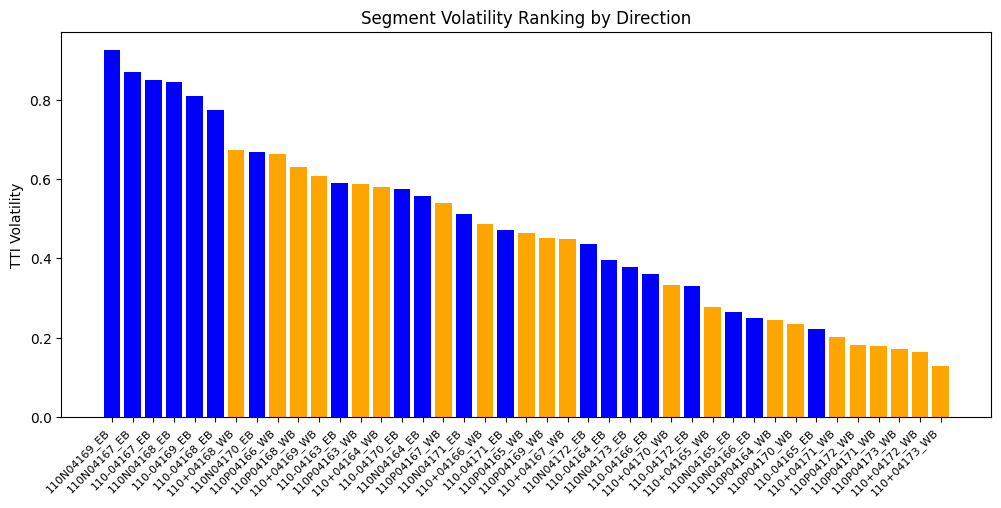

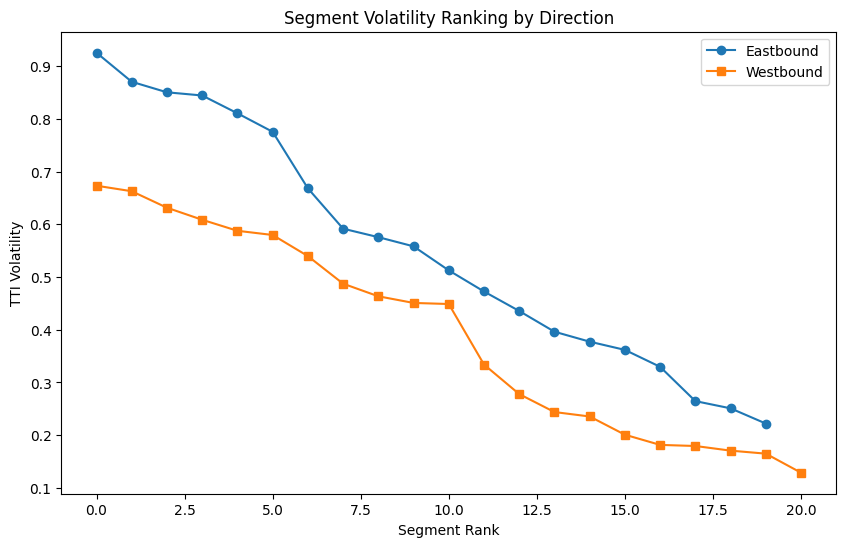

In [ ]:
colors = segment_volatility_sorted["direction"].map({
    "EASTBOUND": "blue",
    "WESTBOUND": "orange"
})

plt.figure(figsize=(12,5))

plt.bar(
    segment_volatility_sorted["tmc_dir"],
    segment_volatility_sorted["tti_volatility"],
    color=colors
)

plt.xticks(rotation=45, fontsize=8, ha="right")
plt.ylabel("TTI Volatility")
plt.title("Segment Volatility Ranking by Direction")
# plt.legend(blue=plt.Line2D([0], [0], color="blue", lw=4), orange=plt.Line2D([0], [0], color="orange", lw=4), labels=["Eastbound", "Westbound"])
plt.savefig(FIG_DIR / "segment_volatility_ranking.png", dpi=200, bbox_inches="tight")
plt.show()

# Separate EB and WB
eb = segment_volatility[segment_volatility["direction"]=="EASTBOUND"].sort_values("tti_volatility", ascending=False)
wb = segment_volatility[segment_volatility["direction"]=="WESTBOUND"].sort_values("tti_volatility", ascending=False)

plt.figure(figsize=(10,6))

plt.plot(eb["tti_volatility"].values, marker="o", label="Eastbound")
plt.plot(wb["tti_volatility"].values, marker="s", label="Westbound")

plt.xlabel("Segment Rank")
plt.ylabel("TTI Volatility")
plt.title("Segment Volatility Ranking by Direction")
plt.legend()
plt.show()

# Section 4 – Horizon Predictability Decay

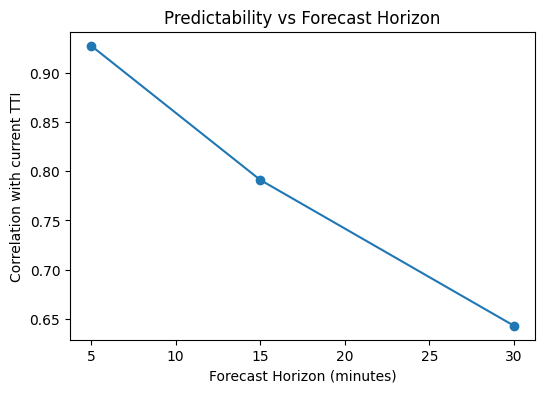

In [ ]:
# Horizon Predictability Decay
# =====================================

horizons = [
    "target_tti_5min_ahead",
    "target_tti_15min_ahead",
    "target_tti_30min_ahead"
]

horizon_corr = []

for h in horizons:
    corr = gold[["tti", h]].corr().iloc[0,1]
    horizon_corr.append(corr)

plt.figure(figsize=(6,4))
plt.plot([5,15,30], horizon_corr, marker="o")
plt.xlabel("Forecast Horizon (minutes)")
plt.ylabel("Correlation with current TTI")
plt.title("Predictability vs Forecast Horizon")
plt.show()

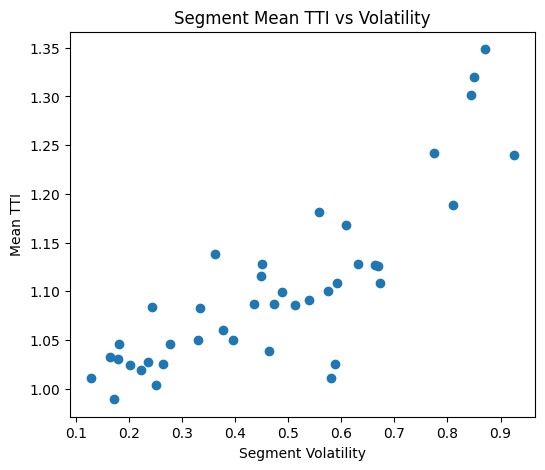

In [ ]:
segment_stats = (
    gold.groupby(["tmc","direction"])
    .agg(
        volatility=("tti","std"),
        mean_tti=("tti","mean")
    )
    .reset_index()
)

plt.figure(figsize=(6,5))
plt.scatter(segment_stats["volatility"], segment_stats["mean_tti"])
plt.xlabel("Segment Volatility")
plt.ylabel("Mean TTI")
plt.title("Segment Mean TTI vs Volatility")
plt.show()

In [ ]:
plt.figure(figsize=(7,5))

plt.hexbin(
    gold["volatility_30min"],
    gold["tti"],
    gridsize=50,
    cmap="Blues"
)

plt.xlabel("Traffic Volatility (30-min)")
plt.ylabel("Travel Time Index (TTI)")
plt.title("Relationship Between Traffic Volatility and Congestion")
plt.colorbar(label="Number of Observations")
plt.tight_layout()
plt.show()

# Section 5 – Volatility vs Future Instability

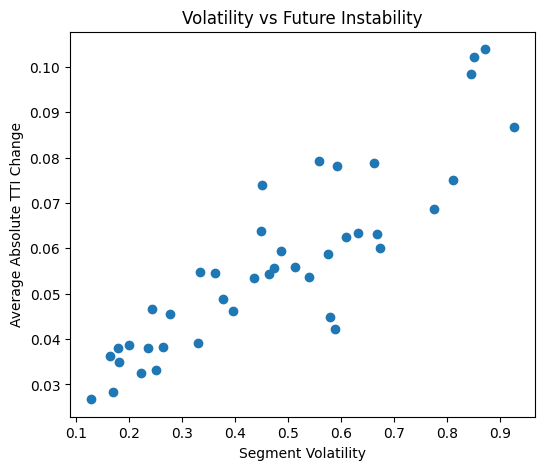

In [ ]:
# Volatility vs Future Instability
# =====================================

vol_future = (
    gold.groupby(["tmc","direction"])
    .agg(
        volatility=("tti","std"),
        future_change=("tti_absolute_change_1_step","mean")
    )
    .reset_index()
)

plt.figure(figsize=(6,5))
plt.scatter(vol_future["volatility"], vol_future["future_change"])
plt.xlabel("Segment Volatility")
plt.ylabel("Average Absolute TTI Change")
plt.title("Volatility vs Future Instability")
plt.show()

## 21. Save notebook-ready final notes

In [ ]:
print("EDA complete.")
print("Figures folder:", FIG_DIR)
print("Tables folder:", TABLE_DIR)

print("\nSuggested first figures to inspect:")
print("1. tti_distribution.png")
print("2. tti_by_hour_direction.png")
print("3. volatility_distribution.png")
print("4. lag_correlation.png")
print("5. horizon_correlation.png")
print("6. future_change_vs_volatility.png")

EDA complete.
Figures folder: c:\Users\asinha\Coding_KAI\_Own_project\Congestion Regime Prediction\notebooks\5_EDA\project_1\outputs_project1_eda\figures
Tables folder: c:\Users\asinha\Coding_KAI\_Own_project\Congestion Regime Prediction\notebooks\5_EDA\project_1\outputs_project1_eda\tables

Suggested first figures to inspect:
1. tti_distribution.png
2. tti_by_hour_direction.png
3. volatility_distribution.png
4. lag_correlation.png
5. horizon_correlation.png
6. future_change_vs_volatility.png
